Exploratory Data Analysis (EDA)

In [ ]:
# =============================================
# STEP 0: Import Libraries for Analysis & Visualization
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [ ]:
# =============================================
# STEP 1: Load Cleaned Dataset
# =============================================
df = pd.read_csv('cleaned_project_dataset.csv', parse_dates=['Start Date', 'End Date'])


=== Descriptive Statistics ===
        Project Cost    Project Benefit   Duration_Days  Completion%  \
count    9.900000e+01       9.900000e+01      99.000000    99.000000   
mean     4.156649e+06       8.828178e+06      96.161616    87.010101   
std      1.076544e+06       2.164019e+05      10.537307     9.942175   
min      2.418301e+06       8.422578e+06      90.000000    72.000000   
25%      3.251948e+06       8.656248e+06      91.000000    78.000000   
50%      4.172827e+06       8.846243e+06      92.000000    86.000000   
75%      5.063288e+06       9.019234e+06      92.000000   100.000000   
max      5.974815e+06       9.165877e+06     120.000000   100.000000   

         Net_Profit  
count  9.900000e+01  
mean   4.671529e+06  
std    1.131156e+06  
min    2.633393e+06  
25%    3.717626e+06  
50%    4.677926e+06  
75%    5.616068e+06  
max    6.720639e+06  
 Project Cost  skewness: 0.09
 Project Benefit  skewness: -0.20
Duration_Days skewness: 1.85
Completion% skewness: 0.17
Ne

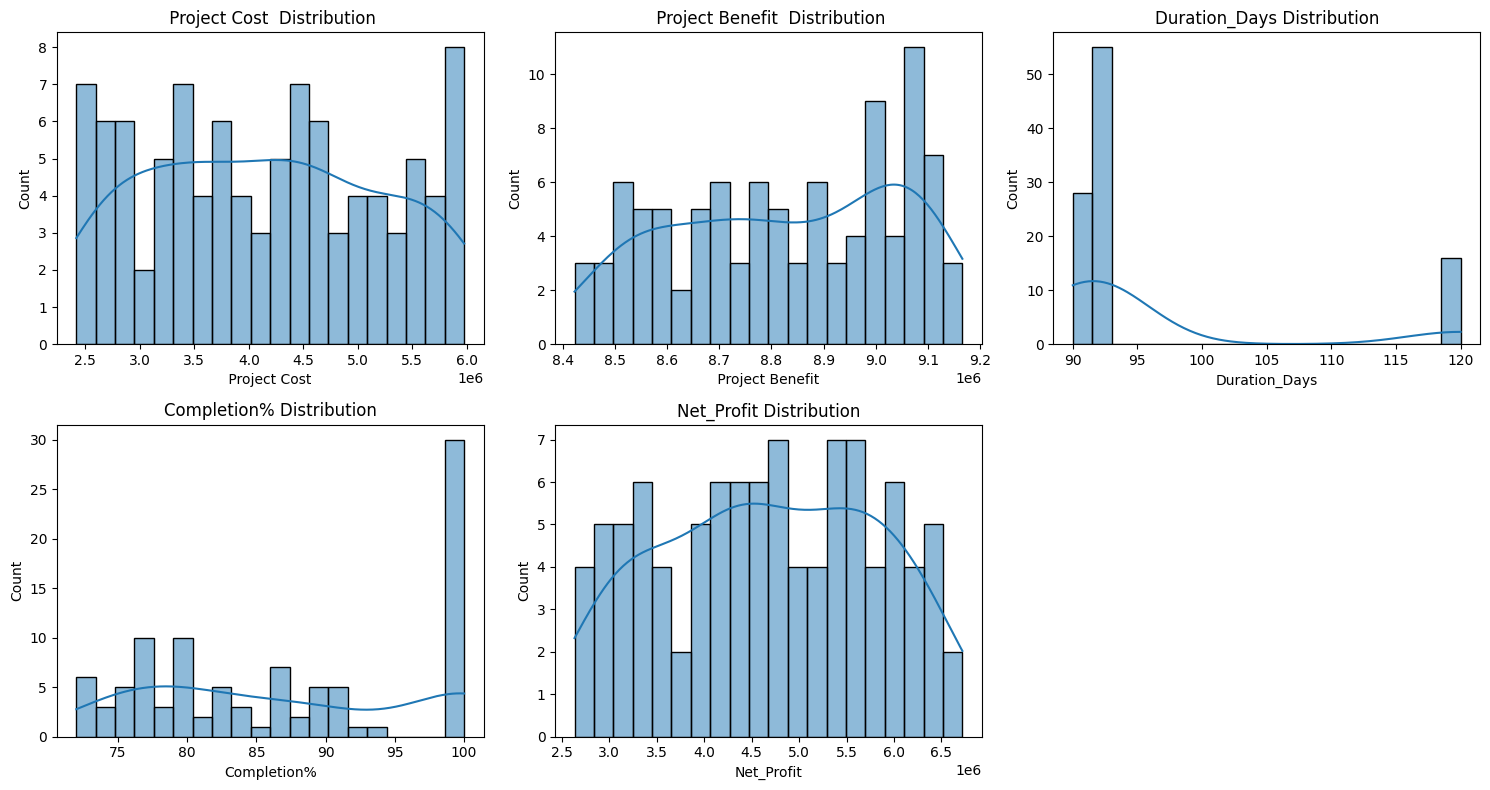

count    99.000000
mean      1.283079
std       0.642793
min       0.442326
25%       0.729386
50%       1.121614
75%       1.650721
max       2.779075
Name: ROI_Ratio, dtype: float64

Projects per Year:
 Year
2021    23
2022    27
2023    17
2024    16
2025    16
Name: count, dtype: int64

Projects per Month:
 Month
1      4
2      4
3      8
4      9
5      8
6      8
7     11
8      9
9     10
10     7
11    13
12     8
Name: count, dtype: int64


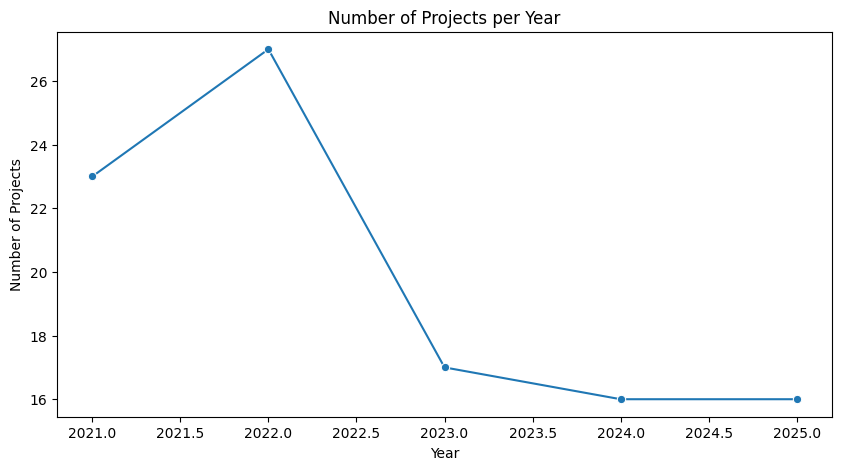


=== Project Type Value Counts ===
Project Type
Income Generation              27
Process Improvement            25
Working Capital Improvement    25
Cost Reduction                 22
Name: count, dtype: int64
Project Type
Income Generation              27.27
Process Improvement            25.25
Working Capital Improvement    25.25
Cost Reduction                 22.22
Name: proportion, dtype: float64


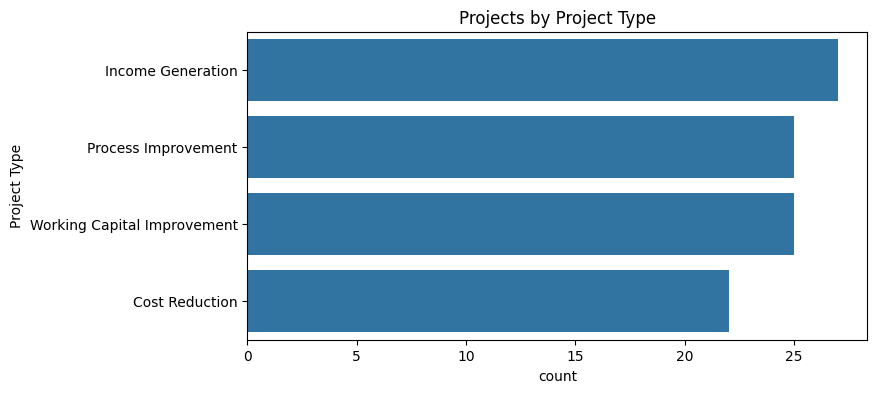


=== Region Value Counts ===
Region
North    34
West     24
South    21
East     20
Name: count, dtype: int64
Region
North    34.34
West     24.24
South    21.21
East     20.20
Name: proportion, dtype: float64


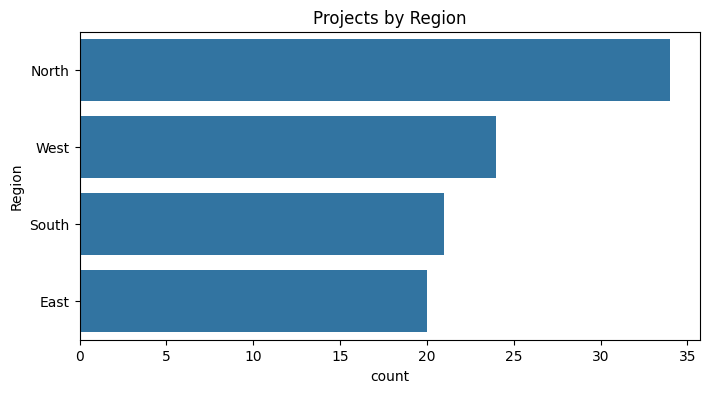


=== Department Value Counts ===
Department
Supply Chain           24
Warehouse              23
Ecommerce              20
Admin & Bi             18
Sales And Marketing    14
Name: count, dtype: int64
Department
Supply Chain           24.24
Warehouse              23.23
Ecommerce              20.20
Admin & Bi             18.18
Sales And Marketing    14.14
Name: proportion, dtype: float64


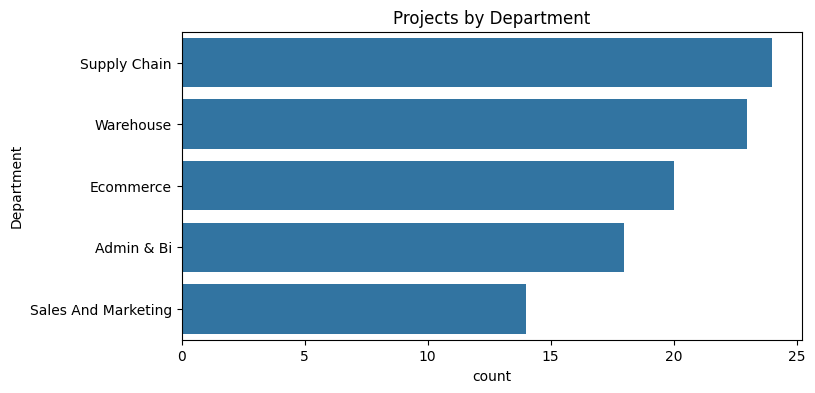


=== Complexity Value Counts ===
Complexity
High      40
Low       30
Medium    29
Name: count, dtype: int64
Complexity
High      40.40
Low       30.30
Medium    29.29
Name: proportion, dtype: float64


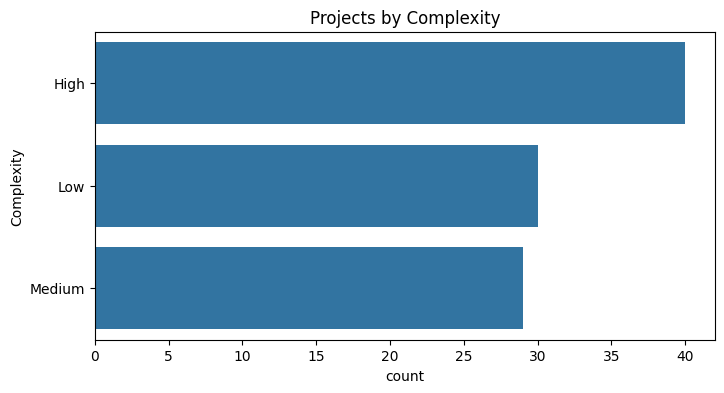


=== Status Value Counts ===
Status
Completed        30
Cancelled        27
In - Progress    25
On - Hold        17
Name: count, dtype: int64
Status
Completed        30.30
Cancelled        27.27
In - Progress    25.25
On - Hold        17.17
Name: proportion, dtype: float64


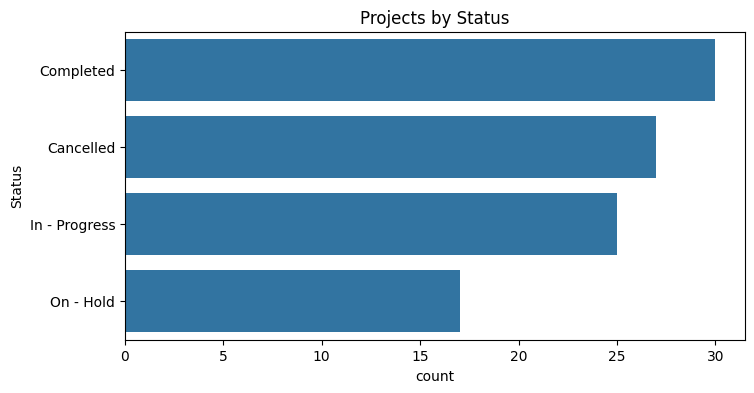


=== Phase Value Counts ===
Phase
Phase 4 - Implement    24
Phase 5 - Measure      23
Phase 2 - Develop      19
Phase 3 - Plan         19
Phase 1 - Explore      14
Name: count, dtype: int64
Phase
Phase 4 - Implement    24.24
Phase 5 - Measure      23.23
Phase 2 - Develop      19.19
Phase 3 - Plan         19.19
Phase 1 - Explore      14.14
Name: proportion, dtype: float64


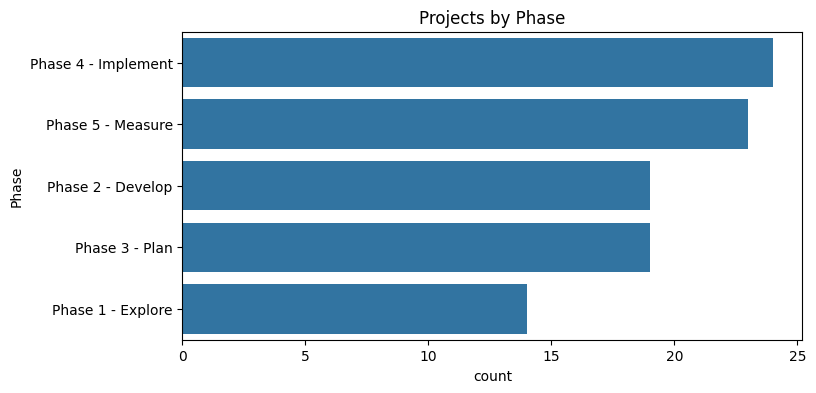


=== Project Manager Value Counts ===
Project Manager
Aleena Khan        18
Brenda Chandler    15
Yael Wilcox        15
Kamari Norris      15
Nyasia Hunter      14
Deacon Delacruz    12
Jaylyn Mckenzie    10
Name: count, dtype: int64
Project Manager
Aleena Khan        18.18
Brenda Chandler    15.15
Yael Wilcox        15.15
Kamari Norris      15.15
Nyasia Hunter      14.14
Deacon Delacruz    12.12
Jaylyn Mckenzie    10.10
Name: proportion, dtype: float64


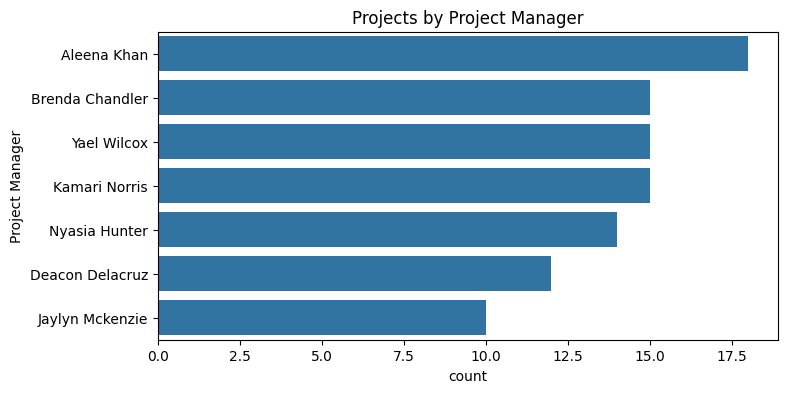

In [ ]:
# =============================================
# STEP 2: Descriptive Statistics
# =============================================

# ----------------------------
# Numerical Columns
# ----------------------------
numeric_cols = [' Project Cost ', ' Project Benefit ', 'Duration_Days', 'Completion%', 'Net_Profit']

# Summary Statistics
print("=== Descriptive Statistics ===")
print(df[numeric_cols].describe())

# Distribution Check (Skewness)
for col in numeric_cols:
    skewness = df[col].skew()
    print(f"{col} skewness: {skewness:.2f}")

# Histogram & Distribution
plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

# ROI Ratio
df['ROI_Ratio'] = (df[' Project Benefit '] - df[' Project Cost ']) / df[' Project Cost ']
print(df['ROI_Ratio'].describe())

# ----------------------------
# Temporal Columns: Year & Month
# ----------------------------
# Count projects per Year
year_counts = df['Year'].value_counts().sort_index()
print("\nProjects per Year:\n", year_counts)

# Count projects per Month
month_counts = df['Month'].value_counts().sort_index()
print("\nProjects per Month:\n", month_counts)

# Trend Line: Projects per Year
plt.figure(figsize=(10,5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Number of Projects per Year')
plt.xlabel('Year')
plt.ylabel('Number of Projects')
plt.show()

# =============================================
# Categorical Columns
# =============================================
categorical_cols = ['Project Type', 'Region', 'Department', 'Complexity', 'Status', 'Phase', 'Project Manager']

for col in categorical_cols:
    print(f"\n=== {col} Value Counts ===")
    print(df[col].value_counts())
    # Percentage Distribution
    print(df[col].value_counts(normalize=True).mul(100).round(2))

    # Bar Plot
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Projects by {col}')
    plt.show()


In [ ]:
# =============================================
# STEP 3: Cross-tab / Comparative Analysis
# =============================================

# Type × Status
type_status = pd.crosstab(df['Project Type'], df['Status'], normalize='index')*100
print("\nType × Status (%)\n", type_status)

# Region × ROI
region_roi = df.groupby('Region')['Net_Profit'].mean().sort_values(ascending=False)
print("\nAverage ROI by Region:\n", region_roi)

# Department × Complexity
dept_complexity = pd.crosstab(df['Department'], df['Complexity'], normalize='index')*100
print("\nDepartment × Complexity (%)\n", dept_complexity)

# Manager × Completion% / ROI
manager_perf = df.groupby('Project Manager')[['Completion%', 'Net_Profit']].mean().sort_values(by='Net_Profit', ascending=False)
print("\nManager Performance:\n", manager_perf)

# Phase × Status
phase_status = pd.crosstab(df['Phase'], df['Status'], normalize='index')*100
print("\nPhase × Status (%)\n", phase_status)



Type × Status (%)
 Status                       Cancelled  Completed  In - Progress  On - Hold
Project Type                                                               
Cost Reduction               18.181818  45.454545      31.818182   4.545455
Income Generation            25.925926  22.222222      29.629630  22.222222
Process Improvement          36.000000  20.000000      24.000000  20.000000
Working Capital Improvement  28.000000  36.000000      16.000000  20.000000

Average ROI by Region:
 Region
West     4.714908e+06
North    4.711594e+06
South    4.622084e+06
East     4.603281e+06
Name: Net_Profit, dtype: float64

Department × Complexity (%)
 Complexity                High        Low     Medium
Department                                          
Admin & Bi           50.000000  22.222222  27.777778
Ecommerce            40.000000  25.000000  35.000000
Sales And Marketing  42.857143  28.571429  28.571429
Supply Chain         37.500000  41.666667  20.833333
Warehouse            34

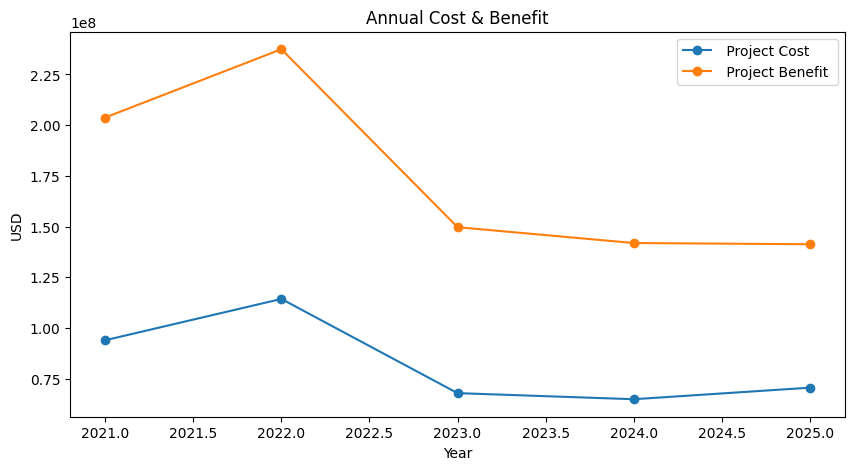

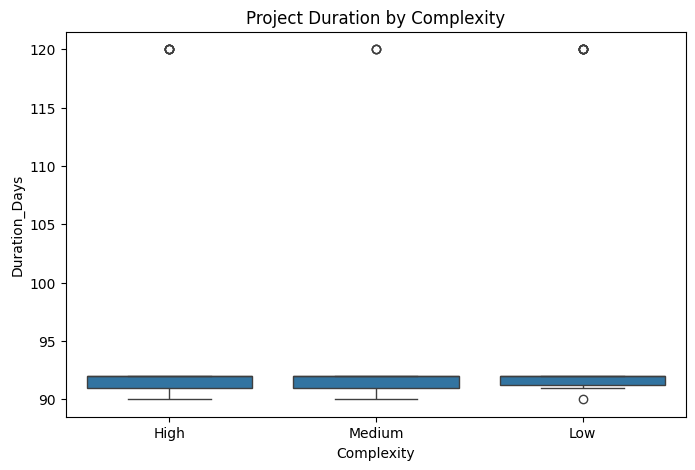

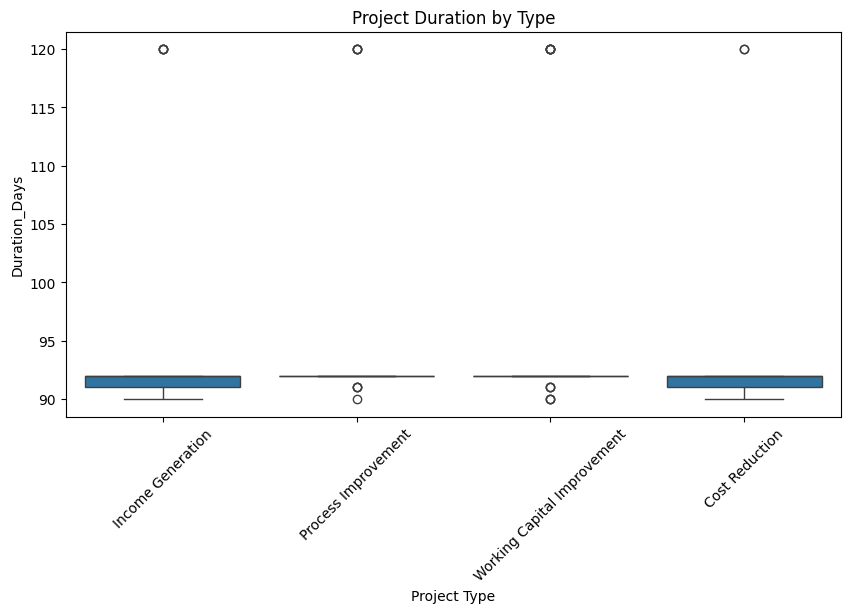

In [ ]:
# =============================================
# STEP 4: Temporal / Time Series Analysis
# =============================================

# Trend of Cost & Benefit per Year
annual_summary = df.groupby('Year')[[' Project Cost ', ' Project Benefit ']].sum()
annual_summary.plot(marker='o', figsize=(10,5))
plt.title('Annual Cost & Benefit')
plt.ylabel('USD')
plt.show()

# Duration distribution by Complexity
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Complexity', y='Duration_Days')
plt.title('Project Duration by Complexity')
plt.show()

# Duration distribution by Project Type
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Project Type', y='Duration_Days')
plt.title('Project Duration by Type')
plt.xticks(rotation=45)
plt.show()

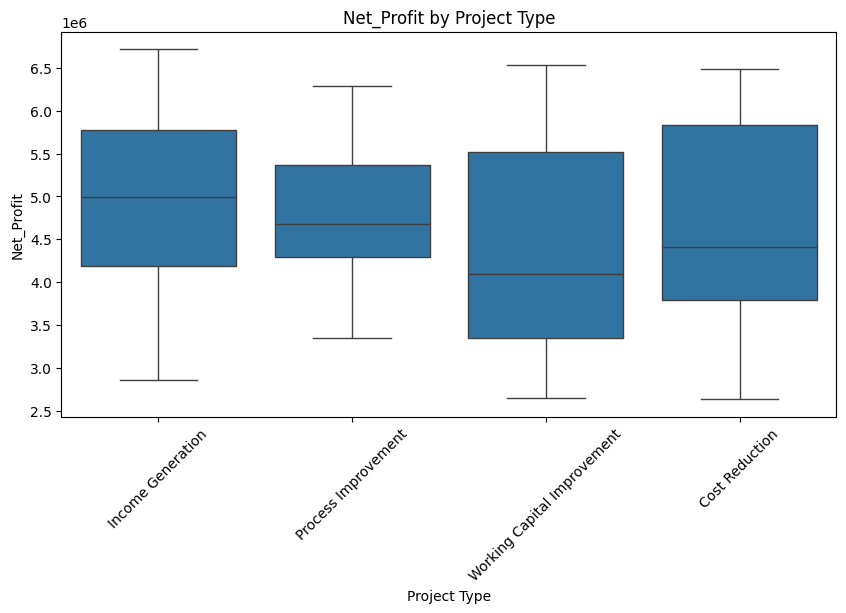

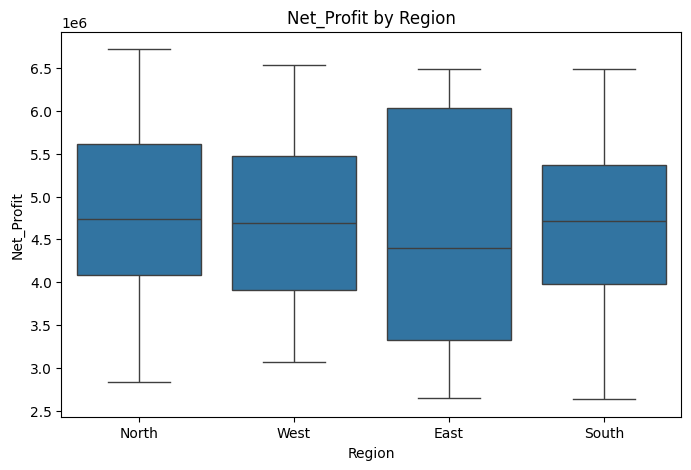

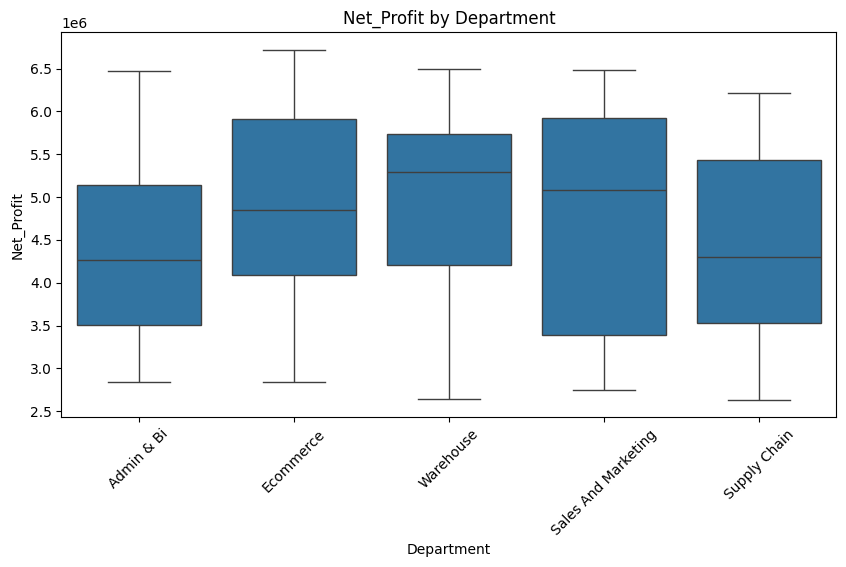


High Cost but Low ROI Projects:
                  Project Name   Project Cost   Net_Profit  ROI_Ratio
3   Remembering Our Ancestors       5285864.0   3433142.0   0.649495
4                    Skyhawks       5785601.0   2844547.0   0.491660
12             Robust Routine       5130016.0   4035861.0   0.786715
13            Passion Chasers       5953512.0   2633393.0   0.442326
20          Annual Award Show       5505123.0   3582888.0   0.650828
22             Static Startup       5869643.0   2933219.0   0.499727
23     The Successful Project       5974815.0   2998816.0   0.501909
27           Great Leadership       5609775.0   3474481.0   0.619362
34              Linkage, Inc.       5913478.0   3182931.0   0.538250
36                       Yoda       5859707.0   2837684.0   0.484271
44       The Experienced Dude       5570834.0   2858541.0   0.513126
47           Mentee To Mentor       5072095.0   3593794.0   0.708542
48            The Code Honors       5896885.0   2642805.0   0.448170


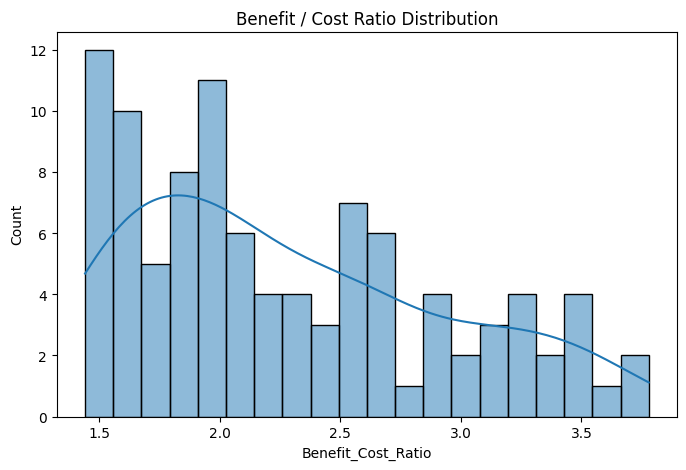

In [ ]:
# =============================================
# STEP 5: Financial Analysis
# =============================================

# Net_Profit by Type
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Project Type', y='Net_Profit')
plt.title('Net_Profit by Project Type')
plt.xticks(rotation=45)
plt.show()

# Net_Profit by Region
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Region', y='Net_Profit')
plt.title('Net_Profit by Region')
plt.show()

# ROI by Department
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Department', y='Net_Profit')
plt.title('Net_Profit by Department')
plt.xticks(rotation=45)
plt.show()

# High Cost but Low ROI Projects
high_cost_low_roi = df[(df[' Project Cost '] > df[' Project Cost '].quantile(0.75)) &
                       (df['ROI_Ratio'] < df['ROI_Ratio'].median())]
print("\nHigh Cost but Low ROI Projects:\n", high_cost_low_roi[['Project Name', ' Project Cost ', 'Net_Profit', 'ROI_Ratio']])

# Benefit/Cost Ratio
df['Benefit_Cost_Ratio'] = df[' Project Benefit '] / df[' Project Cost ']
plt.figure(figsize=(8,5))
sns.histplot(df['Benefit_Cost_Ratio'], bins=20, kde=True)
plt.title('Benefit / Cost Ratio Distribution')
plt.show()



Complexity × Status (%)
 Status      Cancelled  Completed  In - Progress  On - Hold
Complexity                                                
High        27.500000  40.000000      20.000000  12.500000
Low         33.333333  26.666667      20.000000  20.000000
Medium      20.689655  20.689655      37.931034  20.689655


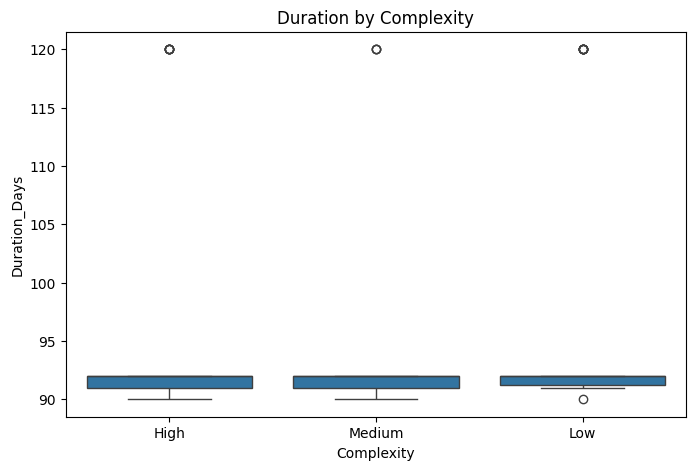

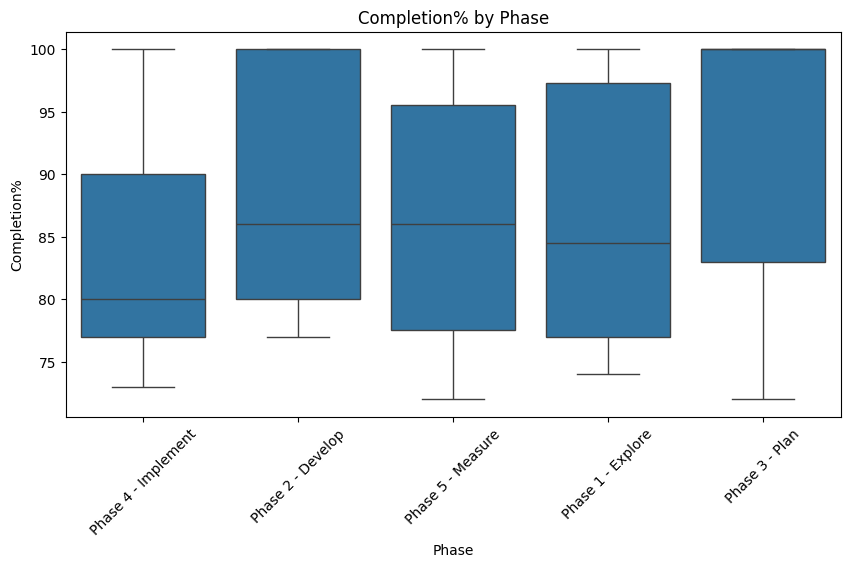

In [ ]:
# =============================================
# STEP 6: Risk & Complexity Analysis
# =============================================

# Complexity × Status
complexity_status = pd.crosstab(df['Complexity'], df['Status'], normalize='index')*100
print("\nComplexity × Status (%)\n", complexity_status)

# Complexity × Duration
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Complexity', y='Duration_Days')
plt.title('Duration by Complexity')
plt.show()

# Phase × Completion%
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Phase', y='Completion%')
plt.title('Completion% by Phase')
plt.xticks(rotation=45)
plt.show()


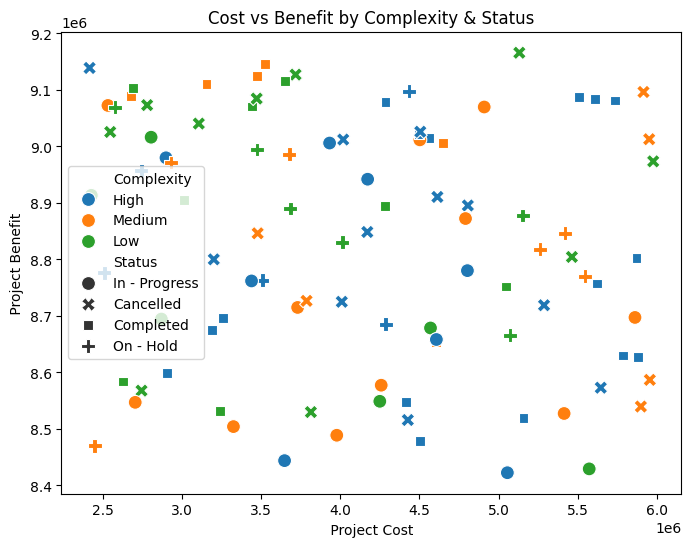

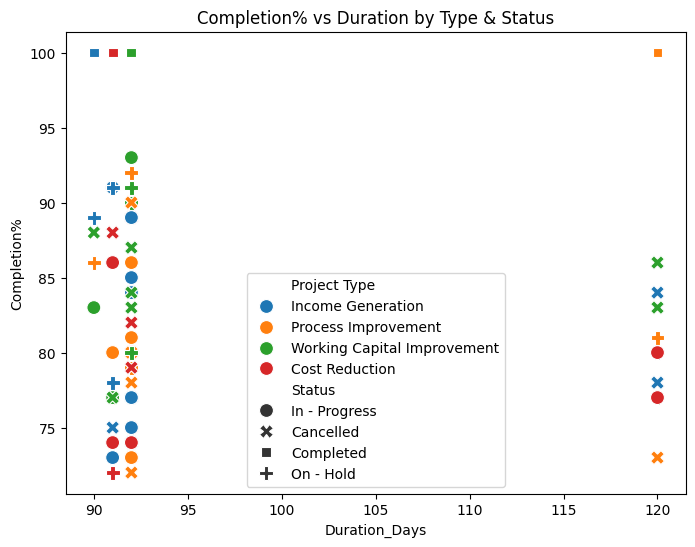

In [ ]:
# =============================================
# STEP 7: Visualization / Scatter Plots
# =============================================

# Cost vs Benefit
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=' Project Cost ', y=' Project Benefit ',
                hue='Complexity', style='Status', s=100)
plt.title('Cost vs Benefit by Complexity & Status')
plt.show()

# Completion% vs Duration
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Duration_Days', y='Completion%',
                hue='Project Type', style='Status', s=100)
plt.title('Completion% vs Duration by Type & Status')
plt.show()